# Startup Success Prediction Project
## Organized Notebook

# 1. Data Loading & Understanding

Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv("big_startup_secsees_dataset.csv")

print(df.shape)
print(df.head())

(66368, 14)
                             permalink                    name  \
0                  /organization/-fame                   #fame   
1               /organization/-qounter                :Qounter   
2  /organization/-the-one-of-them-inc-  (THE) ONE of THEM,Inc.   
3                /organization/0-6-com                 0-6.com   
4       /organization/004-technologies        004 Technologies   

                        homepage_url  \
0                 http://livfame.com   
1             http://www.qounter.com   
2                http://oneofthem.jp   
3                 http://www.0-6.com   
4  http://004gmbh.de/en/004-interact   

                                       category_list funding_total_usd  \
0                                              Media          10000000   
1  Application Platforms|Real Time|Social Network...            700000   
2                                  Apps|Games|Mobile           3406878   
3                                        Curated Web  

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66368 entries, 0 to 66367
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   permalink          66368 non-null  object
 1   name               66367 non-null  object
 2   homepage_url       61310 non-null  object
 3   category_list      63220 non-null  object
 4   funding_total_usd  66368 non-null  object
 5   status             66368 non-null  object
 6   country_code       59410 non-null  object
 7   state_code         57821 non-null  object
 8   region             58338 non-null  object
 9   city               58340 non-null  object
 10  funding_rounds     66368 non-null  int64 
 11  founded_at         51147 non-null  object
 12  first_funding_at   66344 non-null  object
 13  last_funding_at    66368 non-null  object
dtypes: int64(1), object(13)
memory usage: 7.1+ MB


Check Missing Values

In [3]:
df.isnull().sum()

permalink                0
name                     1
homepage_url          5058
category_list         3148
funding_total_usd        0
status                   0
country_code          6958
state_code            8547
region                8030
city                  8028
funding_rounds           0
founded_at           15221
first_funding_at        24
last_funding_at          0
dtype: int64

In [4]:
missing = (df.isnull().sum()/len(df))*100
print(missing.sort_values(ascending=False))

founded_at           22.934245
state_code           12.878194
region               12.099204
city                 12.096191
country_code         10.483968
homepage_url          7.621143
category_list         4.743250
first_funding_at      0.036162
name                  0.001507
permalink             0.000000
status                0.000000
funding_total_usd     0.000000
funding_rounds        0.000000
last_funding_at       0.000000
dtype: float64


Check Duplicate Records

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.drop_duplicates(inplace=True)

Target Column

In [7]:
df['status'].value_counts()

status
operating    53034
closed        6238
acquired      5549
ipo           1547
Name: count, dtype: int64

In [8]:
df['status'].value_counts(normalize=True)*100

status
operating    79.908992
closed        9.399108
acquired      8.360957
ipo           2.330943
Name: proportion, dtype: float64

Visualize Target Distribution

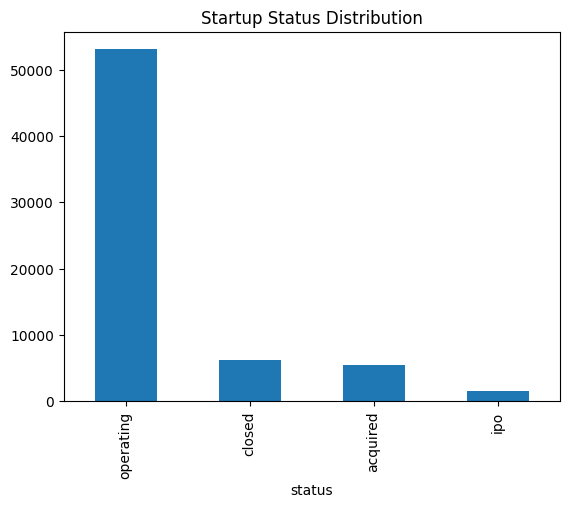

In [9]:
import matplotlib.pyplot as plt

df['status'].value_counts().plot(kind='bar')

plt.title("Startup Status Distribution")
plt.show()

Funding Analysis

In [10]:
df['funding_total_usd'] = pd.to_numeric(
    df['funding_total_usd'],
    errors='coerce'
)

In [11]:
df['funding_total_usd'].describe()

count    5.358300e+04
mean     1.847860e+07
std      1.880133e+08
min      1.000000e+00
25%      3.356235e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

Outlier Detection

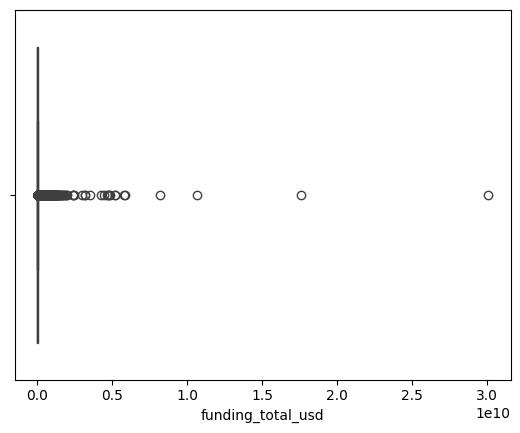

In [12]:
import seaborn as sns

sns.boxplot(x=df['funding_total_usd'])
plt.show()

Category Analysis

In [13]:
df['category_list'].value_counts().head(20)

category_list
Software               3995
Biotechnology          3615
E-Commerce             1332
Mobile                 1177
Clean Technology       1133
Curated Web            1050
Hardware + Software     932
Health Care             930
Games                   862
Enterprise Software     845
Manufacturing           773
Health and Wellness     770
Advertising             700
Education               585
Semiconductors          501
Finance                 447
Real Estate             425
Consulting              423
Security                410
Social Media            407
Name: count, dtype: int64

Country Analysis

In [14]:
df['country_code'].value_counts().head(10)

country_code
USA    37601
GBR     3688
CAN     1925
IND     1596
CHN     1544
FRA     1135
DEU     1082
ISR      965
ESP      746
AUS      503
Name: count, dtype: int64

Funding Rounds Analysis

In [15]:
df['funding_rounds'].describe()

count    66368.000000
mean         1.732522
std          1.360251
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         19.000000
Name: funding_rounds, dtype: float64

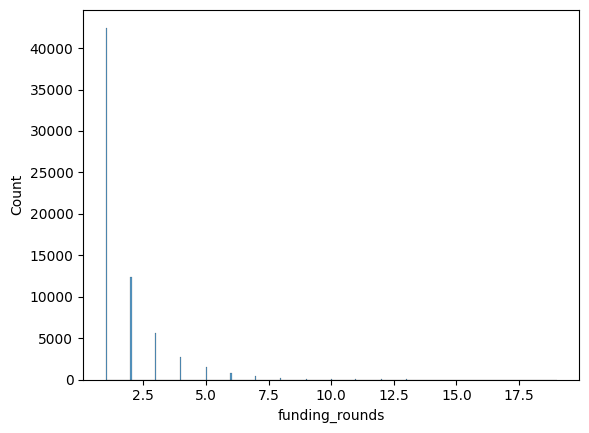

In [16]:
sns.histplot(df['funding_rounds'])

plt.show()

Correlation Analysis

In [17]:
numeric_cols = df.select_dtypes(include=['int64','float64'])

corr = numeric_cols.corr()

print(corr)

                   funding_total_usd  funding_rounds
funding_total_usd           1.000000        0.112909
funding_rounds              0.112909        1.000000


Startup Status Distribution Graph

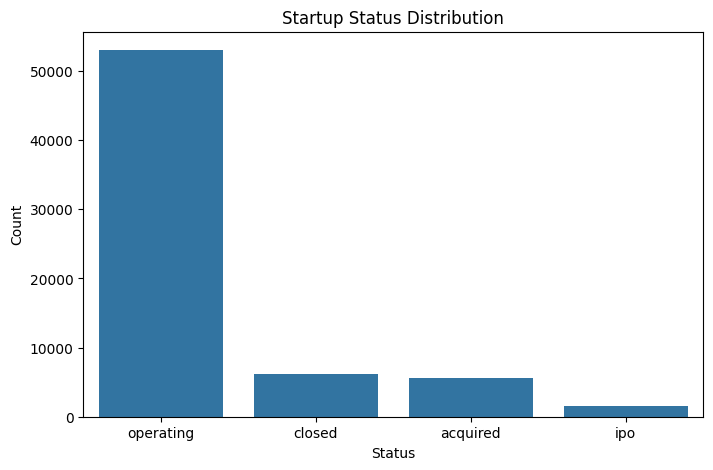

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    x='status',
    data=df,
    order=df['status'].value_counts().index
)

plt.title("Startup Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")

plt.show()

Top 10 Startup Categories

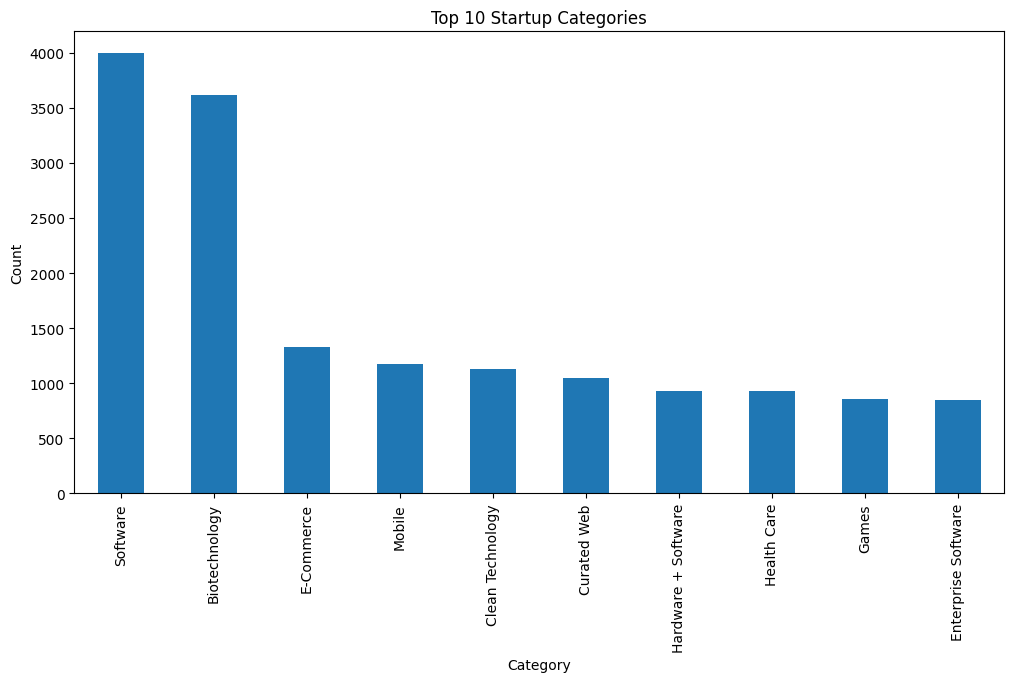

In [19]:
plt.figure(figsize=(12,6))

df['category_list'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Top 10 Startup Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

Top 10 Countries

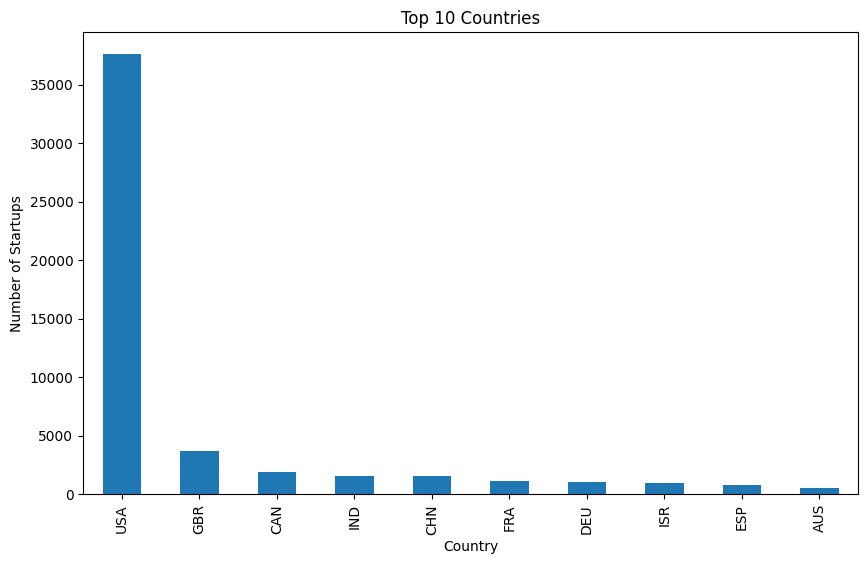

In [20]:
plt.figure(figsize=(10,6))

df['country_code'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Number of Startups")

plt.show()

# 2. Target Creation & Feature Engineering

Create Success Column

In [21]:
df = df[df['status'].isin([
    'acquired',
    'ipo',
    'closed'
])]

df['success'] = df['status'].apply(
    lambda x: 1 if x in ['acquired', 'ipo'] else 0
)

print(df['status'].value_counts())

print("\nSuccess Distribution")

print(df['success'].value_counts())


status
closed      6238
acquired    5549
ipo         1547
Name: count, dtype: int64

Success Distribution
success
1    7096
0    6238
Name: count, dtype: int64


In [22]:
df['success'].value_counts()

success
1    7096
0    6238
Name: count, dtype: int64

Feature Engineering

In [23]:
df['founded_at'] = pd.to_datetime(
    df['founded_at'],
    errors='coerce'
)

df['company_age'] = (
    2026 - df['founded_at'].dt.year
)

In [24]:
df['first_funding_at'] = pd.to_datetime(
    df['first_funding_at'],
    errors='coerce'
)

df['last_funding_at'] = pd.to_datetime(
    df['last_funding_at'],
    errors='coerce'
)

df['funding_duration'] = (
    df['last_funding_at'] -
    df['first_funding_at']
).dt.days

In [25]:
df['funding_per_round'] = (
    df['funding_total_usd'] /
    df['funding_rounds']
)

# 3. Data Preprocessing

In [26]:
data = df.copy()

Drop Unnecessary Columns

In [27]:
data.drop(
    columns=[
        'permalink',
        'name',
        'homepage_url',
        'status',
        'founded_at',
        'first_funding_at',
        'last_funding_at'
    ],
    inplace=True
)

In [28]:
data.columns

Index(['category_list', 'funding_total_usd', 'country_code', 'state_code',
       'region', 'city', 'funding_rounds', 'success', 'company_age',
       'funding_duration', 'funding_per_round'],
      dtype='object')

In [29]:
data.isnull().sum()

category_list        1086
funding_total_usd    2191
country_code         1991
state_code           2209
region               2152
city                 2152
funding_rounds          0
success                 0
company_age          3734
funding_duration        2
funding_per_round    2191
dtype: int64

In [30]:
num_cols = [
    'funding_total_usd',
    'company_age',
    'funding_duration',
    'funding_per_round'
]

In [31]:
for col in num_cols:
    data[col] = data[col].fillna(data[col].median())

In [32]:
cat_cols = [
    'category_list',
    'country_code',
    'state_code',
    'region',
    'city'
]

In [33]:
for col in cat_cols:
    data[col] = data[col].fillna('Unknown')

In [34]:
data.isnull().sum()

category_list        0
funding_total_usd    0
country_code         0
state_code           0
region               0
city                 0
funding_rounds       0
success              0
company_age          0
funding_duration     0
funding_per_round    0
dtype: int64

In [35]:
X = data.drop('success', axis=1)

y = data['success']

In [36]:
y.value_counts()

success
1    7096
0    6238
Name: count, dtype: int64

Train-Test Split

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(10667, 10)
(2667, 10)
success
1    5677
0    4990
Name: count, dtype: int64
success
1    1419
0    1248
Name: count, dtype: int64


Data Preprocessor

In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [40]:
categorical_features = X.select_dtypes(
    include='object'
).columns

numerical_features = X.select_dtypes(
    exclude='object'
).columns

In [41]:
print(categorical_features)
print(numerical_features)

Index(['category_list', 'country_code', 'state_code', 'region', 'city'], dtype='object')
Index(['funding_total_usd', 'funding_rounds', 'company_age',
       'funding_duration', 'funding_per_round'],
      dtype='object')


In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)

In [43]:
from sklearn.model_selection import train_test_split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(10667, 10)
(2667, 10)
success
1    5677
0    4990
Name: count, dtype: int64
success
1    1419
0    1248
Name: count, dtype: int64


# 4. Model Training - Logistic Regression

Logistic Regression

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

log_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [47]:
log_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

Predictions

In [48]:
y_pred = log_model.predict(X_test)

Model Performance

In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.532058492688414
Precision: 0.532058492688414
Recall   : 1.0
F1 Score : 0.6945668135095447


Confusion Matrix

In [50]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[   0 1248]
 [   0 1419]]


In [51]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1248
           1       0.53      1.00      0.69      1419

    accuracy                           0.53      2667
   macro avg       0.27      0.50      0.35      2667
weighted avg       0.28      0.53      0.37      2667



c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [52]:
y.value_counts(normalize=True) * 100

success
1    53.217339
0    46.782661
Name: proportion, dtype: float64

Import Random Forest

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

In [54]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [55]:
rf_pred = rf_model.predict(X_test)


# 5. Model Training - Random Forest

In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Accuracy : 0.7386576677915261
Precision: 0.7317073170731707
Recall   : 0.8033826638477801
F1 Score : 0.7658716829022506


In [57]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, rf_pred))

[[ 830  418]
 [ 279 1140]]


In [58]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.75      0.67      0.70      1248
           1       0.73      0.80      0.77      1419

    accuracy                           0.74      2667
   macro avg       0.74      0.73      0.74      2667
weighted avg       0.74      0.74      0.74      2667



# Hyperparameter Tuning of Random Forest

In [59]:
X_train_encoded = preprocessor.fit_transform(X_train)

X_test_encoded = preprocessor.transform(X_test)

In [60]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

(10667, 7018)
(2667, 7018)


In [61]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=2,
    scoring='f1_macro',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(
    X_train_encoded,
    y_train
)

Fitting 2 folds for each of 5 candidates, totalling 10 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': ['balanced', 'balanced_subsample'], 'max_depth': [10, 15, ...], 'n_estimators': [100, 200]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.2

In [62]:
print(random_search.best_params_)

{'n_estimators': 200, 'max_depth': 20, 'class_weight': 'balanced'}


In [63]:
best_rf = random_search.best_estimator_

rf_tuned_pred = best_rf.predict(X_test_encoded)

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_tuned_pred
))

              precision    recall  f1-score   support

           0       0.76      0.66      0.70      1248
           1       0.73      0.82      0.77      1419

    accuracy                           0.74      2667
   macro avg       0.75      0.74      0.74      2667
weighted avg       0.74      0.74      0.74      2667



In [64]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [65]:
X_train_encoded = preprocessor.fit_transform(X_train)

X_test_encoded = preprocessor.transform(X_test)

In [66]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

(10667, 7018)
(2667, 7018)


In [67]:
%pip install xgboost


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Import XGBoost

# 7. XGBoost & Final Comparison

In [68]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# XGBoost Hyperparameter Tuning (RandomizedSearchCV)

In [69]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=15,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    verbose=2,
    n_jobs=-1
)

xgb_search.fit(X_train_encoded, y_train)


Fitting 3 folds for each of 15 candidates, totalling 45 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used h

In [70]:
print("Best Parameters:")
print(xgb_search.best_params_)

print("\nBest Score:")
print(xgb_search.best_score_)


Best Parameters:
{'subsample': 0.8, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}

Best Score:
0.7352942372154189


In [71]:
best_xgb = xgb_search.best_estimator_
best_xgb


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [72]:
xgb_model.fit(
    X_train_encoded,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [73]:
from sklearn.pipeline import Pipeline

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", xgb_model)
])

In [74]:
final_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [75]:
xgb_pred = xgb_model.predict(
    X_test_encoded
)

In [76]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:",
      accuracy_score(y_test, xgb_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report")
print(classification_report(
    y_test,
    xgb_pred
))

Accuracy: 0.7540307461567304

Confusion Matrix
[[ 854  394]
 [ 262 1157]]

Classification Report
              precision    recall  f1-score   support

           0       0.77      0.68      0.72      1248
           1       0.75      0.82      0.78      1419

    accuracy                           0.75      2667
   macro avg       0.76      0.75      0.75      2667
weighted avg       0.75      0.75      0.75      2667



Model Performance Comparison

In [77]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = []

models = {
    "Logistic Regression": (log_model, X_test),
    "Random Forest": (rf_model, X_test),
    "XGBoost": (xgb_model, X_test_encoded)
}

for name, (model, test_data) in models.items():

    y_pred = model.predict(test_data)

    results.append({
        "Model": name,
        "Accuracy (%)": round(accuracy_score(y_test, y_pred) * 100, 2),
        "Precision (%)": round(precision_score(y_test, y_pred) * 100, 2),
        "Recall (%)": round(recall_score(y_test, y_pred) * 100, 2),
        "F1 Score (%)": round(f1_score(y_test, y_pred) * 100, 2)
    })

results_df = pd.DataFrame(results)

display(results_df.sort_values(
    by="Accuracy (%)",
    ascending=False
))

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
2,XGBoost,75.40,74.60,81.54,77.91
1,Random Forest,73.87,73.17,80.34,76.59
0,Logistic Regression,53.21,53.21,100.00,69.46


In [78]:
print(type(log_model))
print(type(rf_model))
print(type(xgb_model))

<class 'sklearn.pipeline.Pipeline'>
<class 'sklearn.pipeline.Pipeline'>
<class 'xgboost.sklearn.XGBClassifier'>


In [79]:
xgb_model.predict_proba(X_test_encoded[:5])

array([[0.46214855, 0.53785145],
       [0.18103743, 0.8189626 ],
       [0.1195873 , 0.8804127 ],
       [0.04876894, 0.95123106],
       [0.98867726, 0.01132271]], dtype=float32)

In [80]:
import joblib

joblib.dump(final_model, "model.pkl")

print("Pipeline model saved successfully")

Pipeline model saved successfully


In [81]:
print(type(xgb_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [82]:
print(xgb_model.feature_importances_)

[0.         0.         0.         ... 0.00538223 0.0039882  0.00260348]


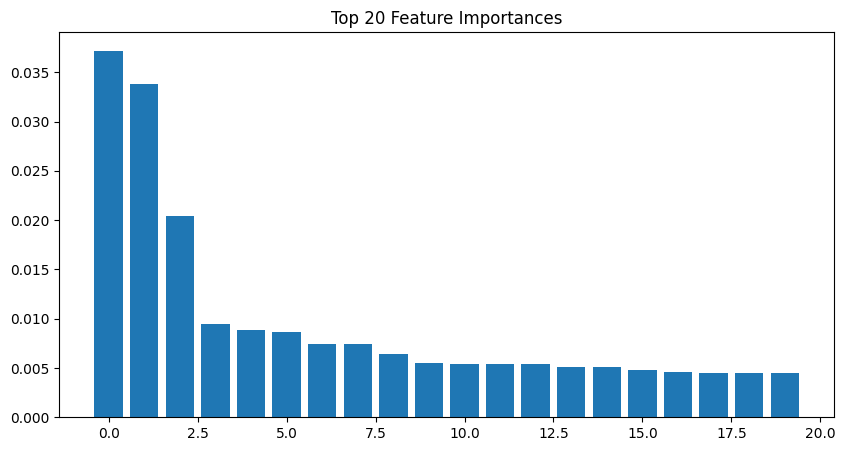

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    range(20),
    sorted(xgb_model.feature_importances_, reverse=True)[:20]
)

plt.title("Top 20 Feature Importances")
plt.show()

In [84]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(20))

                                     Feature  Importance
5460                     cat__region_Unknown    0.037212
4747               cat__country_code_Unknown    0.033841
4635              cat__category_list_Unknown    0.020379
7013            remainder__funding_total_usd    0.009423
4784                      cat__state_code_48    0.008828
4731                   cat__country_code_RUS    0.008611
4746                   cat__country_code_USA    0.007480
6861                       cat__city_Unknown    0.007455
4680                   cat__country_code_CAN    0.006435
4818                      cat__state_code_AB    0.005556
3050  cat__category_list_Enterprise Software    0.005425
5086                   cat__region_Edinburgh    0.005390
7015                  remainder__company_age    0.005382
1574     cat__category_list_Clean Technology    0.005117
5282                    cat__region_Montreal    0.005107
4692                   cat__country_code_FRA    0.004792
6267                   cat__cit

In [85]:
print(type(model))

<class 'xgboost.sklearn.XGBClassifier'>


In [86]:
print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)


# Final Model Comparison and Performance Evaluation

In [87]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = []

try:
    models = {
        "Logistic Regression": (log_model, X_test),
        "Random Forest": (rf_model, X_test),
        "Tuned Random Forest": (best_rf, X_test_encoded),
        "XGBoost": (xgb_model, X_test_encoded),
        "Tuned XGBoost": (best_xgb, X_test_encoded)
    }

    for name, (model, test_data) in models.items():
        y_pred = model.predict(test_data)

        results.append({
            "Model": name,
            "Accuracy (%)": round(accuracy_score(y_test, y_pred) * 100, 2),
            "Precision (%)": round(precision_score(y_test, y_pred) * 100, 2),
            "Recall (%)": round(recall_score(y_test, y_pred) * 100, 2),
            "F1 Score (%)": round(f1_score(y_test, y_pred) * 100, 2)
        })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by="F1 Score (%)", ascending=False)

    display(results_df)

except Exception as e:
    print("Update variable names if needed:", e)


,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
4,Tuned XGBoost,76.00,75.05,82.24,78.48
3,XGBoost,75.40,74.60,81.54,77.91
2,Tuned Random Forest,74.24,73.05,81.75,77.15
1,Random Forest,73.87,73.17,80.34,76.59
0,Logistic Regression,53.21,53.21,100.00,69.46


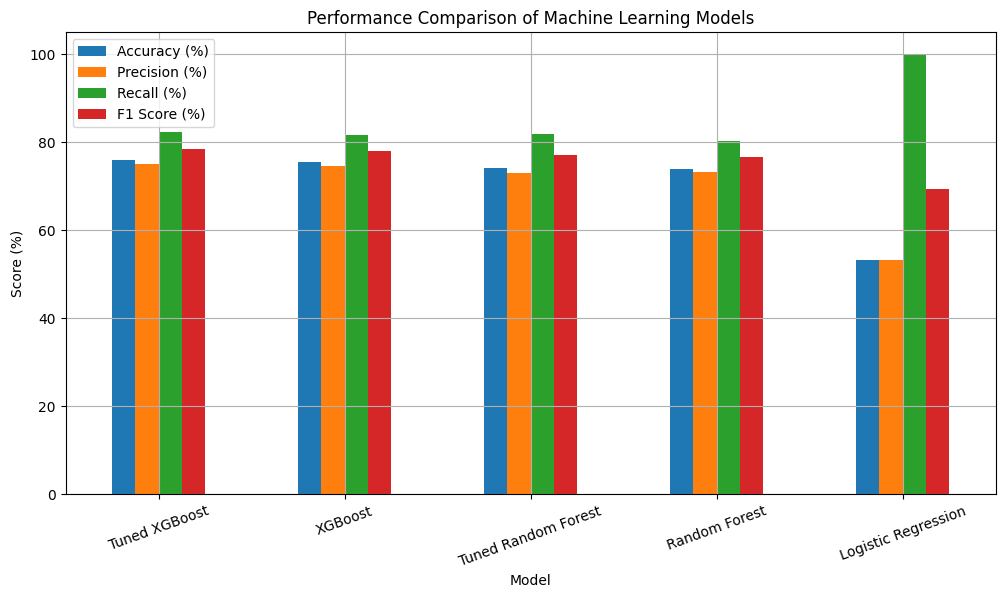

In [88]:
import matplotlib.pyplot as plt

results_df.plot(
    x="Model",
    y=["Accuracy (%)", "Precision (%)", "Recall (%)", "F1 Score (%)"],
    kind="bar",
    figsize=(12,6)
)

plt.title("Performance Comparison of Machine Learning Models")
plt.ylabel("Score (%)")
plt.xticks(rotation=20)
plt.grid(True)
plt.show()


In [89]:
print("Best Model Based On F1 Score")
display(results_df.head(1))


Best Model Based On F1 Score


,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
4,Tuned XGBoost,76.0,75.05,82.24,78.48


In [90]:
from sklearn.pipeline import Pipeline

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", best_xgb)
])

In [91]:
final_model.fit(X_train, y_train)

import joblib
joblib.dump(final_model, "model.pkl")

print("Pipeline model saved successfully")
print(type(final_model))


Pipeline model saved successfully
<class 'sklearn.pipeline.Pipeline'>


In [92]:
import joblib

model = joblib.load("model.pkl")

print(type(model))

<class 'sklearn.pipeline.Pipeline'>
